# BEE 4750 Homework 5: Mixed Integer and Stochastic Programming

**Name**: Eliana Olson 

**ID**: ero23

> **Due Date** 
>
> Thursday, 12/04/24, 9:00pm

## Overview

### Instructions

-   In Problem 1, you will use mixed integer programming to solve a
    waste load allocation problem.
-   In Problem 2, you will formulate a stochastic optimization problem.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [3]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/hw5-ero23_hw5`


In [3]:
using JuMP
using HiGHS
using DataFrames
using GraphRecipes
using Plots
using Measures
using MarkdownTables

## Problems (Total: 30 Points)

### Problem 1 (24 points)

Three cities are developing a coordinated municipal solid waste (MSW)
disposal plan. Three disposal alternatives are being considered: a
landfill (LF), a materials recycling facility (MRF), and a
waste-to-energy facility (WTE). The capacities of these facilities and
the fees for operation and disposal are provided below.

-   **LF**: Capacity 200 Mg, fixed cost \$2000/day, tipping cost
    \$50/Mg;
-   **MRF**: Capacity 350 Mg, fixed cost \$1500/day, tipping cost
    \$7/Mg, recycling cost \$40/Mg recycled;
-   **WTE**: Capacity 210 Mg, fixed cost \$2500/day, tipping cost
    \$60/Mg;

The MRF recycling rate is 40%, and the ash fraction of non-recycled
waste is 16% and of recycled waste is 14%. Transportation costs are
\$1.5/Mg-km, and the relative distances between the cities and
facilities are provided in the table below.

| **City/Facility** | **Landfill (km)** | **MRF (km)** | **WTE (km)** |
|:-----------------:|:-----------------:|:------------:|:------------:|
|         1         |         5         |      30      |      15      |
|         2         |        15         |      25      |      10      |
|         3         |        13         |      45      |      20      |
|        LF         |        \-         |      32      |      18      |
|        MRF        |        32         |      \-      |      15      |
|        WTE        |        18         |      15      |      \-      |

The fixed costs associated with the disposal options are incurred only
if the particular disposal option is implemented. The three cities
produce 100, 90, and 120 Mg/day of solid waste, respectively, with the
composition provided in the table below.

| **Component** | **% of total mass** | **Combustion ash** (%) | **MRF Recycling rate** (%) |
|:---------------------:|:--------------:|:---------------:|:---------------:|
| Food Wastes | 15 | 8 | 0 |
| Paper & Cardboard | 40 | 7 | 55 |
| Plastics | 5 | 5 | 15 |
| Textiles | 3 | 10 | 10 |
| Rubber, Leather | 2 | 15 | 0 |
| Wood | 5 | 2 | 30 |
| Yard Wastes | 18 | 2 | 40 |
| Glass | 4 | 100 | 60 |
| Ferrous | 2 | 100 | 75 |
| Aluminum | 2 | 100 | 80 |
| Other Metal | 1 | 100 | 50 |
| Miscellaneous | 3 | 70 | 0 |

The information in the above table will help you determine the overall
recycling and ash fractions. Note that the recycling residuals, which
may be sent to either landfill or the WTE, have different ash content
than the ash content of the original MSW. You will need to determine
these fractions to construct your mass balance constraints.

**Reminder**: Use `round(x; digits=n)` to report values to the
appropriate precision!

#### Problem 1.1

Based on the information above, calculate the overall recycling and ash
fractions for the waste produced by each city.

In [2]:
RECYCLE_rate= (.15*0+.4*.55+.05*.15+.03*.1+.02*0+.05*.3+.18*.4+.04*.6+.02*.75+.02*.8+.01*.5+.03*0)*100
println("Recycling fraction = ", round(RECYCLE_rate; digits=4),'%') 
ASH_rate = (.15*.08+.4*.07+.05*.05+.03*.1+.02*.15+.05*.02+.18*.02+.04*1+.02*1+.02*1+.01*1+.03*.7)*100
println("Ash fraction = ", round(ASH_rate; digits=4),'%') 

Recycling fraction = 37.75%
Ash fraction = 16.41%


#### Problem 1.2

What are the decision variables for your optimization problem? Provide
notation and variable meaning.

I am using similar decision variables to what we used in the class example...  
Wij = Waste transported from city i to disposal j (Mg/day)  
    cities = (1,2,3)  
    disposal = (MRF, WTE, LF)  
R(1,2,3) = Residual waste transported (MRF-WTE , MRF-LF , WTE-LF) (Mg/day)  
Yj = Operational status (on/off) of disposal j (binary)  

#### Problem 1.3

Formulate the objective function. Make sure to include any needed
derivations or justifications for your equation(s).

In [3]:
Full_MRF_Tipping = 7+(.3775*40) #accounting for only 37.75% of the Mg being recyclable
println("MRF Tipping Cost= ", round(Full_MRF_Tipping; digits=4),'%') 

MRF Tipping Cost= 22.1%


broadly the objective is:  
minimize 
(Wij,Y)

sum(fixed_cost[j]* Y[j] for j in facilities) + sum(tipping[j]* W[i,j] for i in cities, j in facilities) + transport * sum(dist[(i,j)]*W[i,j] for i in cities, j in facilities)

Becuase I updated the MRF tipping cost above I don't need to add anything specical about recycling and can just use that value in the tipping cost calculations!  

I also included my calculations and the exact objective below in the image  
![Calcs for objective and constraints!](figures/HW5_calcs.jpeg)

#### Problem 1.4

Derive all relevant constraints. Make sure to include any needed
justifications or derivations.

The constraints are in the work shown above!

#### Problem 1.5

Find the optimal solution (using `JuMP` to solve the problem). Report
the optimal objective value.

In [6]:
waste_model = Model(HiGHS.Optimizer) # initialize model object

#-------set up...
cities = 1:3
plants = 1:3   # 1=MRF, 2=WTE, 3=LF

#-------non-negativity constraints
@variable(waste_model, W[cities, plants] >= 0)   # waste flows
@variable(waste_model, R[1:3] >= 0)              # residuals:
#R[1]=MRF->WTE , R[2]=MRF->LF , R[3]=WTE->LF

# Syntax from the slides in class!
@variable(waste_model, Y[plants], Bin) 

#Waste totals!
@constraint(waste_model, W[1,1] + W[1,2] + W[1,3] == 100)
@constraint(waste_model, W[2,1] + W[2,2] + W[2,3] == 90)
@constraint(waste_model, W[3,1] + W[3,2] + W[3,3] == 120)

#Residuals from WTE 
@constraint(waste_model,
    R[3] == 0.1641 * (W[1,2] + W[2,2] + W[3,2] + R[1]) #0.1641 = ash rate
)
#Residuals from the MRF
@constraint(waste_model,
     R[1] + R[2] == 0.6225 * (W[1,1] + W[2,1] + W[3,1])  #0.6225 = 1-recycle rate
)
#Plant/Disposal Capacities 
@constraint(waste_model,
    (W[1,1] + W[2,1] + W[3,1]) <= 350 * Y[1]
)
@constraint(waste_model,
    (W[1,2] + W[2,2] + W[3,2] + R[1]) <= 210 * Y[2]
)
@constraint(waste_model,
    (W[1,3] + W[2,3] + W[3,3] + R[2] + R[3]) <= 200 * Y[3]
)

# MRF open condition
@constraint(waste_model, sum(W[:,1]) <= 1000 * Y[1])

#WTE open condition
@constraint(waste_model, sum(W[:,2]) + R[1] <= 1000 * Y[2])

# LF must always be open
@constraint(waste_model, Y[3] == 1)

#My simplified objective function!
@objective(waste_model, Min,
    67.1*W[1,1] + 59.6*W[2,1] + 89.6*W[3,1] +
    82.5*W[1,2] + 75.0*W[2,2] + 90.0*W[3,2] +
    57.5*W[1,3] + 72.5*W[2,3] + 69.5*W[3,3] +
    82.5*R[1] + 98.0*R[2] + 77.0*R[3] +
    1500*Y[1] + 2500*Y[2] + 2000*Y[3]
)
print(waste_model)

Min 67.1 W[1,1] + 59.6 W[2,1] + 89.6 W[3,1] + 82.5 W[1,2] + 75 W[2,2] + 90 W[3,2] + 57.5 W[1,3] + 72.5 W[2,3] + 69.5 W[3,3] + 82.5 R[1] + 98 R[2] + 77 R[3] + 1500 Y[1] + 2500 Y[2] + 2000 Y[3]
Subject to
 W[1,1] + W[1,2] + W[1,3] = 100
 W[2,1] + W[2,2] + W[2,3] = 90
 W[3,1] + W[3,2] + W[3,3] = 120
 -0.1641 W[1,2] - 0.1641 W[2,2] - 0.1641 W[3,2] - 0.1641 R[1] + R[3] = 0
 -0.6225 W[1,1] - 0.6225 W[2,1] - 0.6225 W[3,1] + R[1] + R[2] = 0
 Y[3] = 1
 W[1,1] + W[2,1] + W[3,1] - 350 Y[1] ≤ 0
 W[1,2] + W[2,2] + W[3,2] + R[1] - 210 Y[2] ≤ 0
 W[1,3] + W[2,3] + W[3,3] + R[2] + R[3] - 200 Y[3] ≤ 0
 W[1,1] + W[2,1] + W[3,1] - 1000 Y[1] ≤ 0
 W[1,2] + W[2,2] + W[3,2] + R[1] - 1000 Y[2] ≤ 0
 W[1,1] ≥ 0
 W[2,1] ≥ 0
 W[3,1] ≥ 0
 W[1,2] ≥ 0
 W[2,2] ≥ 0
 W[3,2] ≥ 0
 W[1,3] ≥ 0
 W[2,3] ≥ 0
 W[3,3] ≥ 0
 R[1] ≥ 0
 R[2] ≥ 0
 R[3] ≥ 0
 Y[1] binary
 Y[2] binary
 Y[3] binary


In [7]:
optimize!(waste_model)

Running HiGHS 1.12.0 (git hash: 755a8e027): Copyright (c) 2025 HiGHS under MIT licence terms
MIP has 11 rows; 15 cols; 44 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [2e-01, 1e+03]
  Cost    [6e+01, 2e+03]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+02]
Presolving model
10 rows, 14 cols, 42 nonzeros  0s
8 rows, 13 cols, 36 nonzeros  0s
Presolve reductions: rows 8(-3); columns 13(-2); nonzeros 36(-8) 

Solving MIP model with:
   8 rows
   13 cols (2 binary, 0 integer, 0 implied int., 11 continuous, 0 domain fixed)
   36 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objectiv

In [8]:
# Print the optimal objective value
println("Optimal objective: ", objective_value(waste_model))

# Print waste flows
for i in 1:3, j in 1:3
    println("W[$i,$j] = ", value(W[i,j]))
end

# Print residuals
for k in 1:3
    println("R[$k] = ", value(R[k]))
end

# Print plant open/close decisions
for j in 1:3
    println("Y[$j] = ", value(Y[j]))
end

Optimal objective: 27855.482115085535
W[1,1] = 0.0
W[1,2] = 0.0
W[1,3] = 100.0
W[2,1] = 0.0
W[2,2] = 90.0
W[2,3] = 0.0
W[3,1] = 0.0
W[3,2] = 41.59468835985166
W[3,3] = 78.40531164014834
R[1] = 0.0
R[2] = 0.0
R[3] = 21.59468835985166
Y[1] = 0.0
Y[2] = 1.0
Y[3] = 1.0


#### Problem 1.6

Draw a diagram showing the flows of waste between the cities and the
facilities. Which facilities (if any) will not be used? Does this
solution make sense?

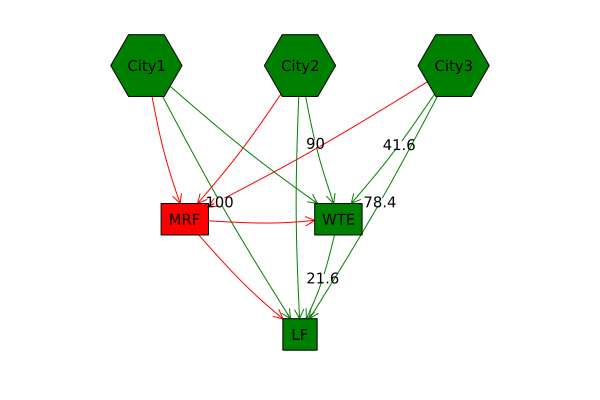

In [71]:
#CHAT GPT used to format the graph
using GraphPlot, Colors

# -------- Nodes --------
names = ["City1", "City2", "City3", "MRF", "WTE", "LF"]
shapes = [:hexagon, :hexagon, :hexagon, :rect, :rect, :rect]
xpos = [-2, 0, 2, -1.5, 0.5, 0]
ypos = [2, 2, 2, 0, 0, -1.5]

# -------- Adjacency matrix --------
A = [
    0 0 0 1 1 1;
    0 0 0 1 1 1;
    0 0 0 1 1 1;
    0 0 0 0 1 1;
    0 0 0 0 0 1;
    0 0 0 0 0 0
]

# -------- Edge labels --------
edge_labels = Dict(
    (1,4) => "", (1,5) => "", (1,6) => "100",
    (2,4) => "", (2,5) => "90", (2,6) => "",
    (3,4) => "", (3,5) => "41.6", (3,6) => "78.4",
    (4,5) => "", (4,6) => "", (5,6) => "21.6"
)

# -------- Edge colors (red if going to or coming from MRF, green if flow, gray if 0) --------
edge_colors = Array{Colorant}(undef, size(A)...)
for i in 1:size(A,1)
    for j in 1:size(A,2)
        if i == 4 || j == 4
            # Edge connected to MRF
            edge_colors[i,j] = colorant"red"
        elseif A[i,j] != 0
            # Flow exists but not connected to MRF
            edge_colors[i,j] = colorant"green"
        else
            # No flow
            edge_colors[i,j] = colorant"gray"
        end
    end
end

# -------- Node colors (MRF red, others green) --------
node_colors = [colorant"green", colorant"green", colorant"green",
               colorant"red", colorant"green", colorant"green"]

# -------- Plot --------
p = graphplot(A, names=names, edgelabel=edge_labels,
              markersize=0.4, markershapes=shapes,
              markercolor=node_colors, x=xpos, y=ypos,
              fontsize=10, edgecolor=edge_colors)

display(p)


This didn't really make sense to me...  
The MRF plant wasn't used at all despite having the lowest costs for every aspect. Having thought about it more I think this could be due to distances, or the hidh residual rate out of the MRF, because if less than half of the material could actually be recycled then it was being sent there just to be transported to another disposal location after, meaning adding even more costs. It was still very surprising for me to see that result. 

### Problem 2 (6 points)

Consider a two-period economic dispatch problem, based on the
multi-period example from Lecture 14 (on 10/29). The generator data,
including ramping constraints for each generator, is provided in
\`data/generators.csv.’ In period 1, the demand is
$d_1 = 1100 \text{MW}$. In period 2, the demand is projected to be
$d_2 = 1200 \text{MW}$, but there is a 25% probability that it is \$1500
. In the first period, the solar capacity factor is $0.9$ and the wind
capacity factor is $0.45$, but in the second period, there is some
uncertainty: the forecasted solar and wind capacity factors are $0.95$
and $0.4$, respectively, but there is a 30% probability that they are
$0.75$ and $0.5$. Your goal is to identify how to dispatch your
generators to minimize the cost of meeting demand.

#### Problem 2.1

Draw a scenario tree for this problem.

#### Problem 2.2

Formulate a stochastic linear program for this problem based on your
scenario tree from Problem 2.1 and the data in `data/generators.csv`.

## References

List any external references consulted, including classmates.